## Preamble

In [45]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator

def resample2d(data, ni1, ni2, di1, di2, no1, no2, do1, do2):
    # 1. Reconstruct original physical coordinate axes
    xi1 = np.arange(ni1) * di1
    xi2 = np.arange(ni2) * di2
    
    # 2. Create the interpolator function from the original grid
    # bounds_error=False and fill_value=None allows extrapolation if grids do not align perfectly
    interp_func = RegularGridInterpolator((xi1, xi2), data, method='linear', 
                                         bounds_error=False, fill_value=None)
    
    # 3. Generate target physical coordinate axes
    xo1 = np.arange(no1) * do1
    xo2 = np.arange(no2) * do2
    
    # 4. Create a 2D mesh grid of target points for evaluation
    # 'ij' indexing matches the shape layout of the matrix (rows, columns)
    XO1, XO2 = np.meshgrid(xo1, xo2, indexing='ij')
    
    # 5. Reshape to a list of (x1, x2) coordinate pairs for the interpolator
    target_points = np.stack([XO1.ravel(), XO2.ravel()], axis=-1)
    
    # 6. Evaluate and reshape back to the target 2D shape
    resampled_array = interp_func(target_points).reshape(no1, no2)
    
    return resampled_array
    
def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

## Herten model line0

Roncoroni et al., 2025

nz,nx = 278, 640
dz,dx = 27, 25 (mm)

In [3]:
!segyread tape=../01_ForwardModeling/line0_eps_25mm.sgy  | suflip flip=3 | sustrip > epsr
!segyread tape=../01_ForwardModeling/line0_mu_25mm.sgy   | suflip flip=3 | sustrip > mur
!segyread tape=../01_ForwardModeling/line0_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma
#!segyread tape=/home/wzhou/DATA/GPR_Roncoroni/data/SEGY/models/sigma/line3_sigm_25mm.sgy | suflip flip=3 | sustrip > sgma

3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00254411 s, 1.3 MB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00359234 s, 891 kB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00239421 s, 1.3 MB/s
n1=278 n2=640 d1=0.001179
nt=278 ntr=640 dt=0.001179
ns=278


In [46]:
epsr=read('epsr' ,(640,278))
mur =read('mur'  ,(640,278))
sgma=read('sgma',(640,278))

c = 299/np.sqrt(epsr*mur)
print('cmin,cmax =',c.min(),c.max())

print('sgmamin,sgmamax =',sgma.min(),sgma.max())

cmin,cmax = 60.230625 92.11606
sgmamin,sgmamax = 0.00188607 0.011641629


## TE Ey-Ey 50 MHz

In [47]:
fpeak = 50 #MHz

λmin = c.min()/fpeak/2
print('λmin, λmin/5 =',λmin,λmin/5)

h=0.12 #m

nz=int(278*0.027/h)
nx=int(640*0.025/h)
print(f'nz,nx = {nz,nx}')
nzsnap=nz+48
nxsnap=nx+48
nsnap=50
print(f'nzsnap,nxsnap = {nzsnap,nxsnap}')

dt_CFL = 0.6*h/299.80 #v.max()
print('dt_CFL =',dt_CFL) #μs
dt = 0.000240 #μs. SU_DT = 240 ps

T=0.3 #μs
print('T=0.3 μs gives nt = ',int(T/dt))
nt=1250
# t=np.arange(0,nt*dt,dt)

nr=160

λmin, λmin/5 = 0.60230625 0.12046125
nz,nx = (62, 133)
nzsnap,nxsnap = (110, 181)
dt_CFL = 0.00024016010673782518
T=0.3 μs gives nt =  1250


In [48]:
def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(nr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=17):
    tmp=np.fromfile(filename,dtype='float32').reshape(n).T
    return tmp[:,:,i]

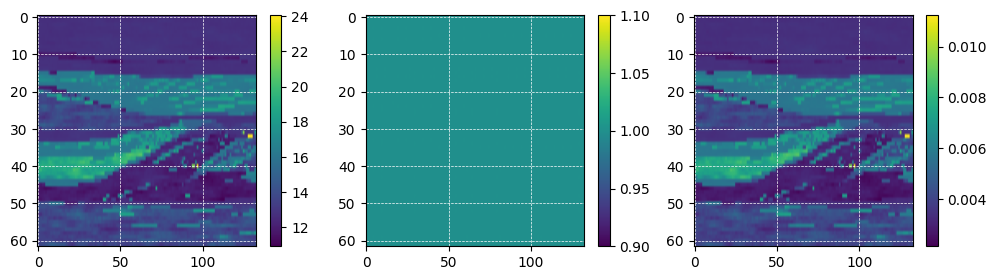

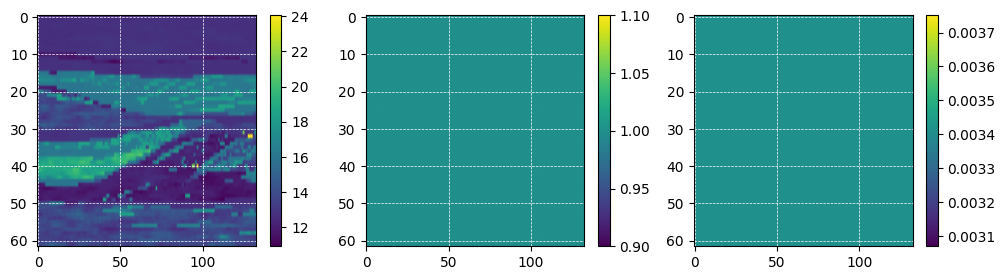

In [49]:
# resample
epsr= resample2d(read('epsr',(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
mur = resample2d(read('mur' ,(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)
sgma= resample2d(read('sgma',(640,278)), 278,640, 0.027,0.025, nz,nx, h,h)

#true model
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(epsr)
plt.subplot(1,3,2); imshow(mur)
plt.subplot(1,3,3); imshow(sgma)

model=np.concat((epsr,mur,sgma),axis=1)
model.T.astype('float32').tofile('true')

#background model
sgma[:,:] = sgma[0,0]

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(epsr)
plt.subplot(1,3,2); imshow(mur)
plt.subplot(1,3,3); imshow(sgma)

model=np.concat((epsr,mur,sgma),axis=1)
model.T.astype('float32').tofile('init')

In [60]:
%%writefile setup_default

MODEL_SIZE              '62    133   1'
MODEL_SPACING           '0.12  0.12  1'
MODEL_ORIGIN            '0     0     0'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'epsr mur sgma'
#NAIRL                    0

ACQUI_GEOMETRY          spread
FS                      '  0    6  0'
FR                      '  0    0  0'
DR                      '  0  0.1  0'
NR                       160

SU_SCALCO               '-10'

IF_HICKS                 T

SCOMP                    Ey
RCOMP                    Ey

FPEAK                    50

NT                       1250
DT                       0.000240
WAVELET_TYPE             ricker

SNAPSHOT                'Hx Hz Ey'


### for inversion ###
FILE_DATA_PREFIX        'res_obs/Ru_Shot'
WEIGHTING               'none'

PARAMETER               'sgma:0:0.012'

SMOOTHING               'none'
#PRECO         'z^0'

#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'

IF_USE_CHECKPOINT        F

Overwriting setup_default


### Obs & Syn data

In [59]:
!cp setup_default setup
!echo "DIR_OUT     res_obs" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 635424 Jun 26 23:46 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 953cd92
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2026
System time: 23:52:08
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_obs
 Output directory:res_obs/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.494(3D)

In [61]:
!cp setup_default setup
!echo "DIR_OUT     res_init" >> setup
!echo "FILE_MODEL  init" >> setup
run(app='../../exe/fwd_TE_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 635424 Jun 26 23:46 ../../exe/fwd_TE_FDSG_O4_
 Git Commit: 953cd92
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2026
System time: 23:52:39
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : res_init
 Output directory:res_init/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606(for 2D) or 0.494(3

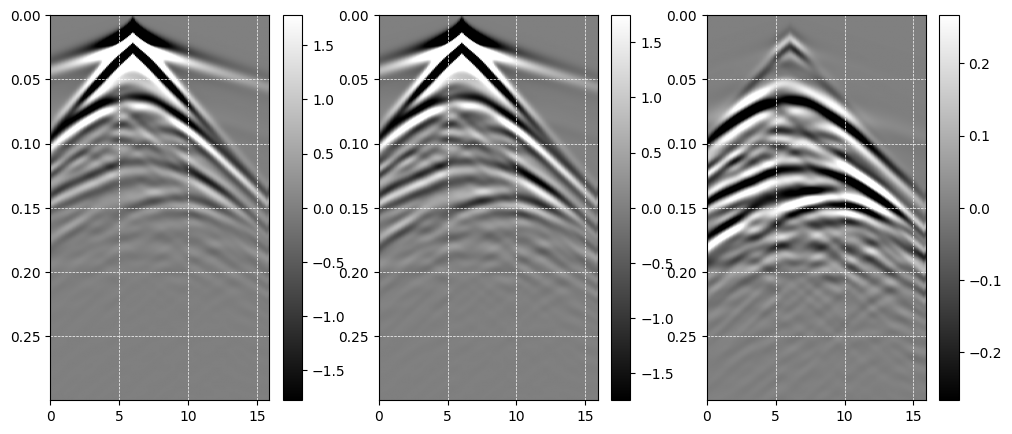

In [62]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1); imshow(read_su('res_obs/Ru_Shot0001.su',(nr,nt)),cmap='gray',extent=[0,0.1*(nr-1),dt*(nt-1),0],perc=95)
plt.subplot(1,3,2); imshow(read_su('res_init/Ru_Shot0001.su',(nr,nt)),cmap='gray',extent=[0,0.1*(nr-1),dt*(nt-1),0],perc=95)
plt.subplot(1,3,3); imshow(read_su('res_obs/Ru_Shot0001.su',(nr,nt)) \
                         - read_su('res_init/Ru_Shot0001.su',(nr,nt)),cmap='gray',extent=[0,0.1*(nr-1),dt*(nt-1),0],perc=95)

### Gradient

#### fwi_TE_FDSG_O4_epsr-mur-sgma

In [63]:
!cp setup_default setup
!echo "FILE_MODEL   init" >> setup
!echo 'JOB     gradient' >> setup
run(app='../../exe/fwi_TE_FDSG_O4_epsr-mur-sgma_Wolfe_NLCG_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/joey/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 joey joey 930000 Jun 26 23:47 ../../exe/fwi_TE_FDSG_O4_epsr-mur-sgma_Wolfe_NLCG_
 Git Commit: 953cd92
 Git Branch: GPR
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 06/26/2026
System time: 23:52:47
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain isotropic Transverse Electric (TE) wave propagation
1st-order H-E formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt 

 it----         500
 fld_a minmax values:  -187.989487       213.167343    
 fld_u minmax values:  -1.72540569       1.54152346    
 Elapsed time to load boundary            7.24416971E-03
 Elapsed time to update E       0.111130059    
 Elapsed time to rm source E     1.79952383E-03
 Elapsed time to update H         0.122708917    
 Total elapsed time for forward (min)   4.04804433E-03
  ---------------------------- 
 Elapsed time to add adjsource E    5.30344248E-03
 Elapsed time to update adj E      0.119026363    
 Elapsed time to update adj H        0.128425062    
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   3.81058455E-03
 Total elapsed time for adjoint&correlate (min)   4.27609077E-03
 Total elapsed time (min):   8.32413509E-03
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_rfield%*  n1=249 perc=99
 xmovie < snap_rfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g
 ximage < snap_*  n1=201 perc

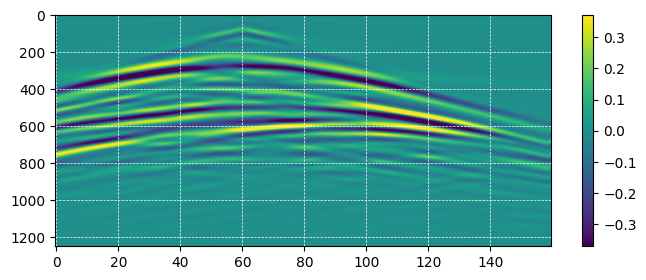

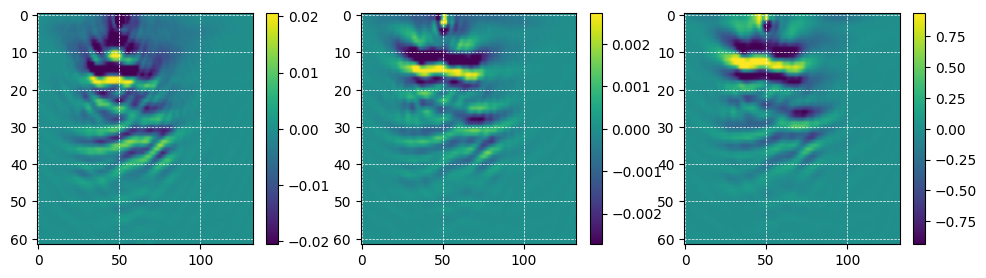

In [64]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su',(nr,nt)),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz)) #gmur gepsr gsgma
plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(corr[:,:nx],perc=98)
plt.subplot(1,4,2); imshow(corr[:,nx:2*nx],perc=98)
plt.subplot(1,4,3); imshow(corr[:,2*nx:],perc=98)

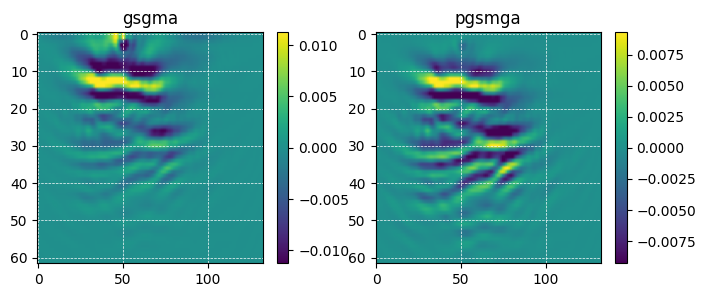

In [65]:
corr=read('results/qp0%g')
plt.figure(figsize=(8,3))
plt.subplot(1,2,1); imshow(read('results/qp0%g' ),perc=98,title='gsgma')
plt.subplot(1,2,2); imshow(read('results/qp0%pg'),perc=98,title='pgsmga')

### gradienttest_TE_FDSG_O4_epsr-mur-sgma

#### on gsgma

In [66]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "ALPHAS '1e-10 1e-9 1e-8 1e-7 1e-6 1e-5' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_epsr-mur-sgma  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   1.00000001E-10   18577.6328       18577.6328       0.00000000      -220435264.            -Infinity T
 1st cond   9.99999972E-10   18577.6328       18577.6328       0.00000000      -220435264.            -Infinity T
 1st cond   9.99999994E-09   18576.1426       18577.6328      -149023440.      -220435264.       1.47919858     T
 1st cond   1.00000001E-07   18556.2305       18577.6328      -214023440.      -220435264.       1.02995849     T
 1st cond   9.99999997E-07   18359.1406       18577.6328      -218492192.      -220435264.       1.00889313     T
 1st cond   9.99999975E-06   16493.0254       18577.6328      -208460752.      -220435264.       1.05744255     T


In [67]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
# !echo 'FILE_TOPO   topo' >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_TE_FDSG_O4_epsr-mur-sgma  setup > out

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    ratio   if_1st_cond
 1st cond   9.99999975E-06   16493.0254       18577.6328      -208460752.      -220435264.       1.05744255     T
 1st cond   9.99999975E-05   7958.96289       18577.6328      -106186704.      -220435264.       2.07592154     T
 1st cond   1.00000005E-03   377877.781       18577.6328       359300128.      -220435264.     -0.613512874     F
 1st cond   9.99999978E-03   1104862.75       18577.6328       108628512.      -220435264.      -2.02925777     F
 1st cond  0.100000001       1239267.75       18577.6328       12206901.0      -220435264.      -18.0582504     F
 1st cond   1.00000000       1216954.88       18577.6328       1198377.25      -220435264.      -183.944794     F


Alpha must be <1e-4 to be reasonable..